In [1]:
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from torchvision.models import resnet18
import torchvision.transforms as transforms

In [2]:
image = Image.open("test/apple.jpg")

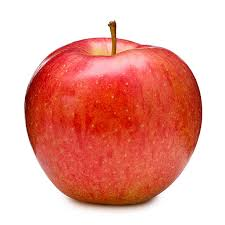

In [3]:
image

In [4]:
preprocess = transforms.Compose(
    [
        transforms.Resize(224),
        transforms.ToTensor()
    ]
)

In [5]:
img = preprocess(image).unsqueeze(0)

In [6]:
img.shape

torch.Size([1, 3, 224, 224])

In [7]:
model = resnet18(pretrained=True)

C:\Users\praveenchakra.bh\AppData\Local\Programs\Python\Python39\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\praveenchakra.bh\AppData\Local\Programs\Python\Python39\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [8]:
class MyHooks:
    def __init__(self):
        self.layer_out = []
        self.layer_out_shape = []

    def __call__(self, modules, modules_input, modules_output):
        self.layer_out.append(modules_output)
        self.layer_out_shape.append(modules_output.shape)

In [9]:
hooks = MyHooks()
for l in model.modules():
    if isinstance(l, torch.nn.modules.conv.Conv2d):
        handle = l.register_forward_hook(hooks)

In [10]:
y_pred = model(img)

In [11]:
## Now we can check the output of the intermediate layers

len(hooks.layer_out)

20

In [12]:
layer_num = 0
layer_images = hooks.layer_out[layer_num].detach().numpy()

In [13]:
print(layer_images.shape)

(1, 64, 112, 112)


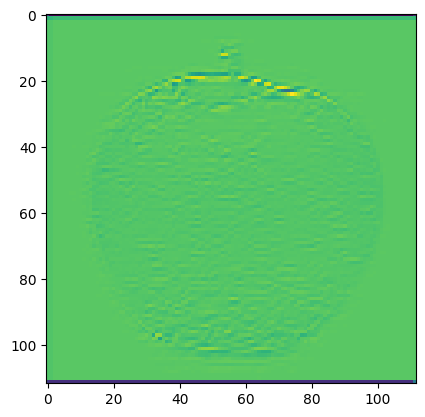

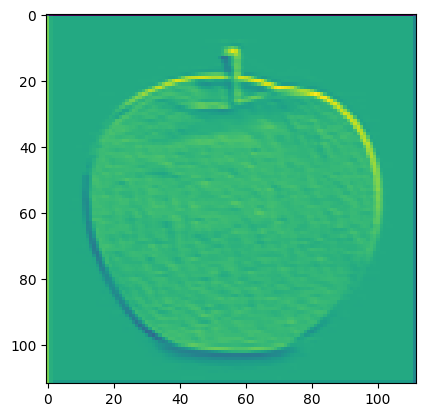

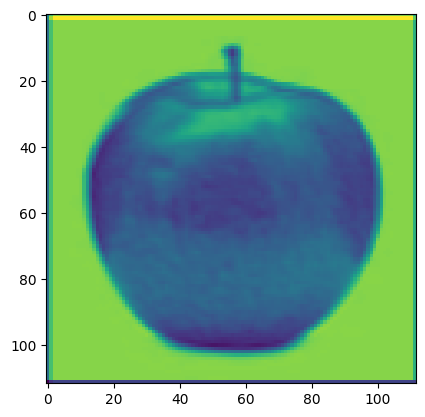

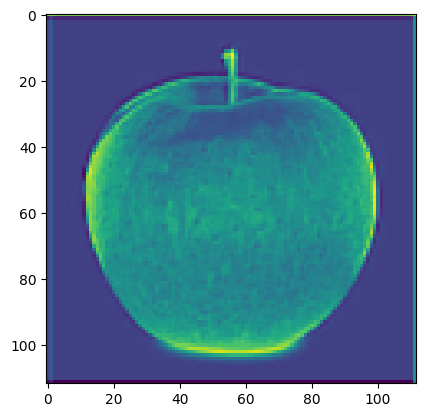

In [14]:
for i in range(4):
    plt.imshow(layer_images[0, i, :, :])
    plt.show()

In [15]:
layer_num = 4
layer_images = hooks.layer_out[layer_num].detach().numpy()

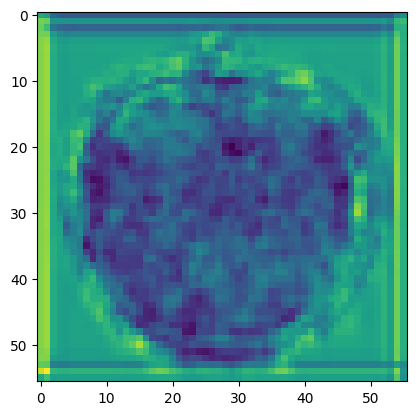

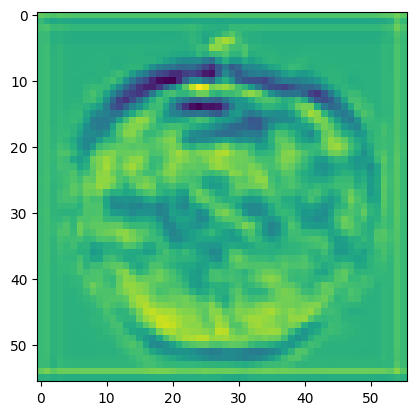

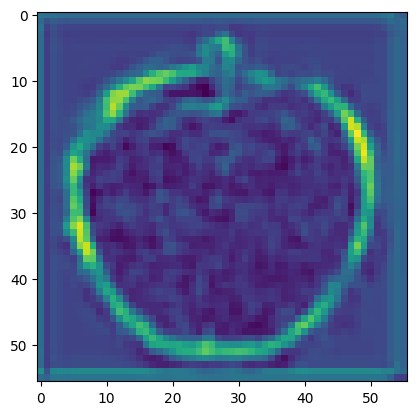

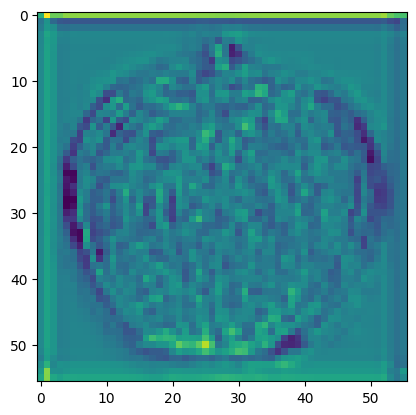

In [16]:
for i in range(4):
    plt.imshow(layer_images[0, i, :, :])
    plt.show()